In [1]:
import pandas as pd
df = pd.read_csv('../data/customer_reviews.csv')
df.head(6)

,review_id,product_name,category,rating,review_text,true_sentiment,reviewer_age,helpful_votes,Unnamed: 8
0,1 Laptop,NaN,Books,NaN,5 Super happy wit,h,Positive,35,45.0
1,2 Laptop,NaN,Home & Kitchen,NaN,5 Works like a ch,a,Positive,61,16.0
2,3 Jeans,NaN,Beauty,NaN,5 Fantastic produ,c,Positive,27,41.0
3,NaN,4 Blender,Sports,NaN,5 Works like a ch,a,Positive,22,11.0
4,NaN,5 Yoga Mat,Books,NaN,4 Works like a ch,a,Positive,26,47.0
5,6 Jeans,NaN,Electronics,NaN,4 Best purchase I Positive,NaN,19,45,NaN


In [1]:
import re
import pandas as pd

raw_lines = pd.read_csv('../data/customer_reviews.csv', header=None, dtype=str).fillna('').astype(str).values.tolist()
records = []

for row in raw_lines[1:]:
    parts = [part.strip() for part in row]
    id_product = parts[0] or parts[1]
    if not id_product:
        continue

    id_parts = id_product.split(' ', 1)
    if len(id_parts) != 2:
        continue

    review_id, product_name = id_parts
    rating_match = re.match(r'^(\d+)\s*(.*)$', parts[4])
    if not rating_match:
        continue

    rating = int(rating_match.group(1))
    review_text = rating_match.group(2).strip()
    fragment = parts[5]
    if fragment and not fragment.isdigit() and fragment.lower() not in {'positive', 'negative'}:
        review_text = f'{review_text}{fragment}'

    review_text = re.sub(r'\s+(positive|negative)\s*$', '', review_text, flags=re.IGNORECASE).strip()
    numeric_values = [int(part) for part in parts if part.isdigit()]
    if len(numeric_values) < 2:
        continue

    true_sentiment = 'Negative' if any('negative' in part.lower() for part in parts) else 'Positive'

    records.append({
        'review_id': int(review_id),
        'product_name': product_name,
        'category': parts[2] or pd.NA,
        'rating': rating,
        'review_text': review_text,
        'true_sentiment': true_sentiment,
        'reviewer_age': numeric_values[-2],
        'helpful_votes': numeric_values[-1],
    })

cleaned_df = pd.DataFrame(records).drop_duplicates().reset_index(drop=True)
cleaned_df.isnull().sum(), cleaned_df.head(6)

(review_id         0
 product_name      0
 category          0
 rating            0
 review_text       0
 true_sentiment    0
 reviewer_age      0
 helpful_votes     0
 dtype: int64,
    review_id product_name        category  rating       review_text  \
 0          1       Laptop           Books       5  Super happy with   
 1          2       Laptop  Home & Kitchen       5  Works like a cha   
 2          3        Jeans          Beauty       5  Fantastic produc   
 3          4      Blender          Sports       5  Works like a cha   
 4          5     Yoga Mat           Books       4  Works like a cha   
 5          6        Jeans     Electronics       4   Best purchase I   
 
   true_sentiment  reviewer_age  helpful_votes  
 0       Positive            35             45  
 1       Positive            61             16  
 2       Positive            27             41  
 3       Positive            22             11  
 4       Positive            26             47  
 5       Positive

In [2]:
eda_df = cleaned_df.copy()

print('Shape:', eda_df.shape)
print('\nColumns:', list(eda_df.columns))
print('\nMissing values:')
print(eda_df.isnull().sum())
print('\nDuplicate rows:', eda_df.duplicated().sum())

print('\nData types:')
print(eda_df.dtypes)

print('\nNumeric summary:')
display(eda_df.describe())

print('\nCategorical summary:')
display(eda_df.describe(include=['string']))

print('\nSentiment distribution:')
display(eda_df['true_sentiment'].value_counts())

print('\nCategory distribution:')
display(eda_df['category'].value_counts().head(10))

print('\nTop products:')
display(eda_df['product_name'].value_counts().head(10))

print('\nAverage rating by category:')
display(eda_df.groupby('category', as_index=False)['rating'].mean().sort_values('rating', ascending=False))

print('\nAverage helpful votes by sentiment:')
display(eda_df.groupby('true_sentiment', as_index=False)['helpful_votes'].mean())

print('\nCorrelation matrix:')
display(eda_df[['rating', 'reviewer_age', 'helpful_votes']].corr())

Shape: (1113, 8)

Columns: ['review_id', 'product_name', 'category', 'rating', 'review_text', 'true_sentiment', 'reviewer_age', 'helpful_votes']

Missing values:
review_id         0
product_name      0
category          0
rating            0
review_text       0
true_sentiment    0
reviewer_age      0
helpful_votes     0
dtype: int64

Duplicate rows: 0

Data types:
review_id         int64
product_name        str
category            str
rating            int64
review_text         str
true_sentiment      str
reviewer_age      int64
helpful_votes     int64
dtype: object

Numeric summary:


,review_id,rating,reviewer_age,helpful_votes
count,1113.000000,1113.000000,1113.00000,1113.000000
mean,593.643306,3.335130,41.14106,23.955076
std,347.832693,1.376837,13.44797,14.301977
min,1.000000,1.000000,18.00000,0.000000
25%,293.000000,2.000000,30.00000,11.000000
50%,586.000000,4.000000,41.00000,23.000000
75%,893.000000,5.000000,53.00000,36.000000
max,1200.000000,5.000000,64.00000,49.000000



Categorical summary:


,product_name,category,review_text,true_sentiment
count,1113,1113,1113,1113
unique,12,6,30,2
top,Face Cream,Clothing,Works like a cha,Positive
freq,115,224,66,790



Sentiment distribution:


...

,category,rating
2,Clothing,3.473214
4,Home & Kitchen,3.377622
5,Sports,3.350000
0,Beauty,3.327957
3,Electronics,3.235294
1,Books,3.219653



Average helpful votes by sentiment:


,true_sentiment,helpful_votes
0,Negative,23.213622
1,Positive,24.258228



Correlation matrix:


,rating,reviewer_age,helpful_votes
rating,1.000000,-0.020526,0.016064
reviewer_age,-0.020526,1.000000,0.005826
helpful_votes,0.016064,0.005826,1.000000


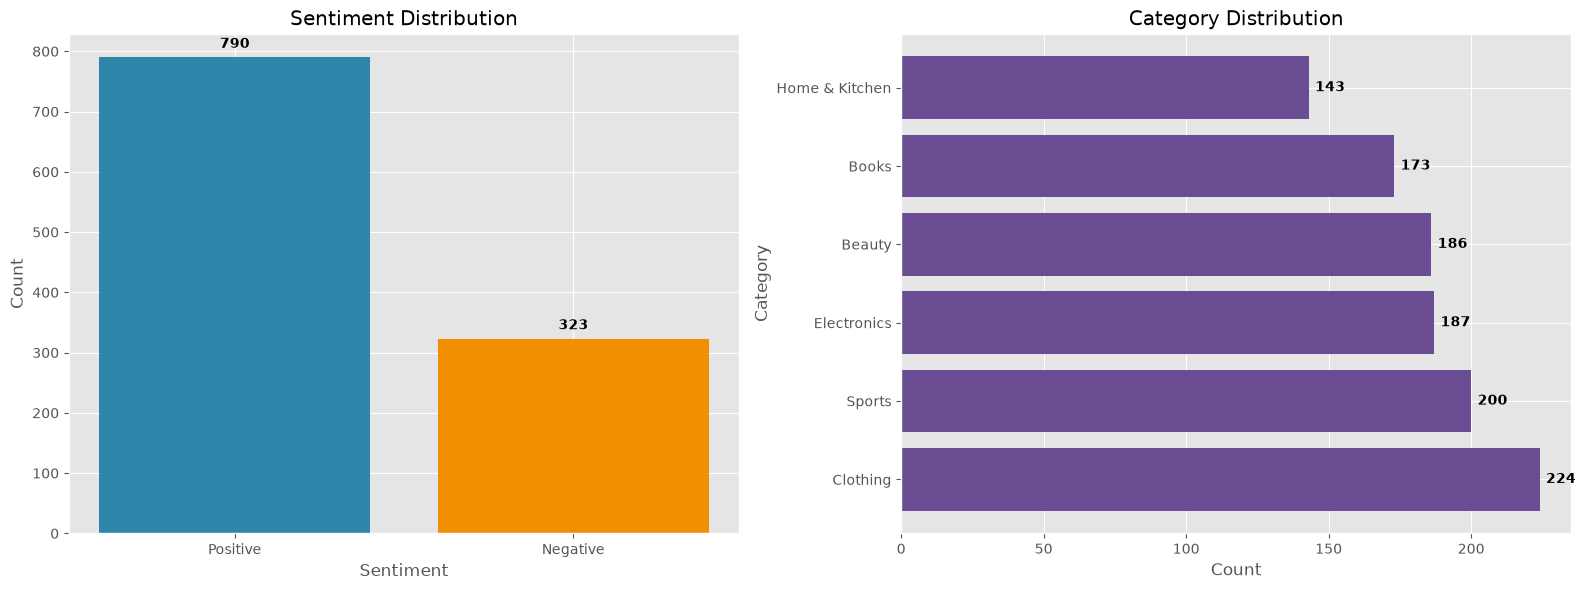

In [3]:
import matplotlib.pyplot as plt

sentiment_counts = eda_df['true_sentiment'].value_counts()
category_counts = eda_df['category'].value_counts()

plt.style.use('ggplot')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=['#2E86AB', '#F18F01'])
axes[0].set_title('Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for index, value in enumerate(sentiment_counts.values):
    axes[0].text(index, value + max(sentiment_counts.values) * 0.02, str(value), ha='center', fontweight='bold')

axes[1].barh(category_counts.index, category_counts.values, color='#6A4C93')
axes[1].set_title('Category Distribution')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Category')
for index, value in enumerate(category_counts.values):
    axes[1].text(value + max(category_counts.values) * 0.01, index, str(value), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

Train size: 890
Test size: 223

Model comparison:


,Model,Accuracy,F1 Score
0,Logistic Regression,1.0,1.0
1,Naive Bayes,1.0,1.0
2,SVM,1.0,1.0
3,Random Forest,1.0,1.0



Best model: Logistic Regression

Classification report for best model:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        65
    Positive       1.00      1.00      1.00       158

    accuracy                           1.00       223
   macro avg       1.00      1.00      1.00       223
weighted avg       1.00      1.00      1.00       223



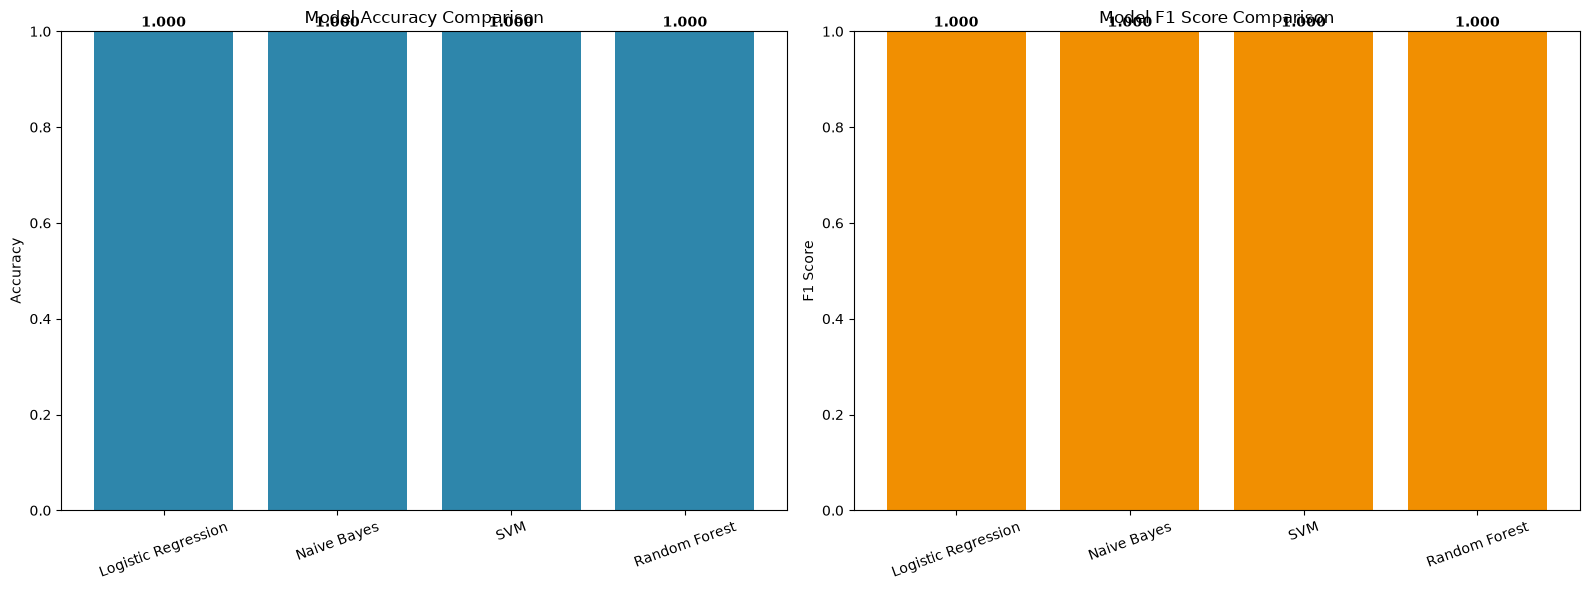

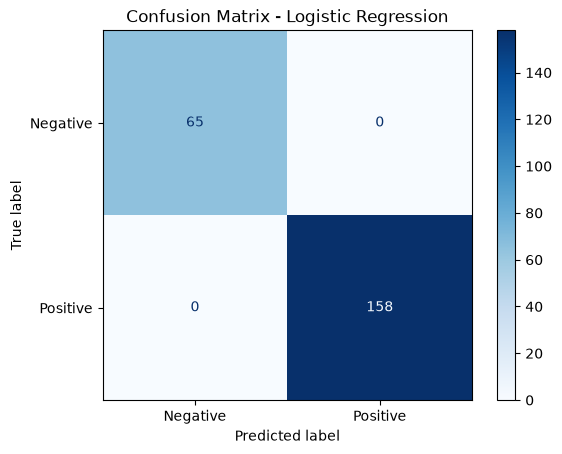

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

model_df = cleaned_df[['review_text', 'true_sentiment']].dropna().copy()
X = model_df['review_text']
y = model_df['true_sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes': MultinomialNB(),
    'SVM': LinearSVC(),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42)
}

results = []
trained_models = {}

for name, estimator in models.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=5000)),
        ('model', estimator)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred, average='weighted')
    })
    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values(['F1 Score', 'Accuracy'], ascending=False).reset_index(drop=True)
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_predictions = best_model.predict(X_test)

print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])
print('\nModel comparison:')
display(results_df)
print('\nBest model:', best_model_name)
print('\nClassification report for best model:')
print(classification_report(y_test, best_predictions))

cm = confusion_matrix(y_test, best_predictions, labels=best_model.classes_)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(results_df['Model'], results_df['Accuracy'], color='#2E86AB')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)
for index, value in enumerate(results_df['Accuracy']):
    axes[0].text(index, value + 0.01, f'{value:.3f}', ha='center', fontweight='bold')

axes[1].bar(results_df['Model'], results_df['F1 Score'], color='#F18F01')
axes[1].set_title('Model F1 Score Comparison')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=20)
for index, value in enumerate(results_df['F1 Score']):
    axes[1].text(index, value + 0.01, f'{value:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_).plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()